#### Luksuitpiti
-67070098
-67070141
-67070190
-67070307

### ปล. ใช้ pdf จากอันนี้ https://office.kmitl.ac.th/oaq/curriculum/ เปลี่ยนชื่อเป็น doc.pdf

In [100]:
import cv2, numpy as np, matplotlib.pyplot as plt

# EX1

In [ ]:
import cv2
import numpy as np
import fitz  

pdf_path = '/Users/pawarit/Downloads/lab2/doc.pdf' #ใส่ path ไฟล์ pdf ครับ
doc = fitz.open(pdf_path)

all_pages_gray = []

for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    pix = page.get_pixmap(dpi=150)
    
    # 1. จำลองภาพหน้า PDF ให้เป็นข้อมูลไฟล์ภาพ (JPEG) พักไว้ใน RAM
    img_bytes = np.frombuffer(pix.tobytes("jpeg"), np.uint8)
    
    # 2. ให้ OpenCV อ่านภาพจาก RAM แทนการอ่านไฟล์จาก Harddisk (ทำหน้าที่แทน cv2.imread)
    img_bgr = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # ---------------------------------------------------------
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    gray = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)
    # ---------------------------------------------------------
    
    all_pages_gray.append(gray)
doc.close()



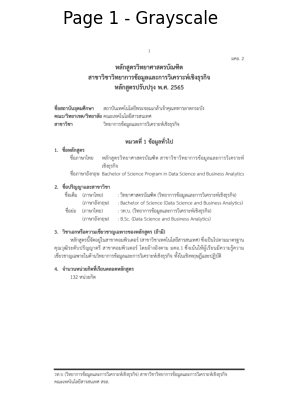

In [111]:
# เลือกหน้าแรก (Index 0) จาก List
plt.imshow(all_pages_gray[1], cmap='gray')
plt.axis('off')
plt.title("Page 1 - Grayscale")
plt.show()

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)



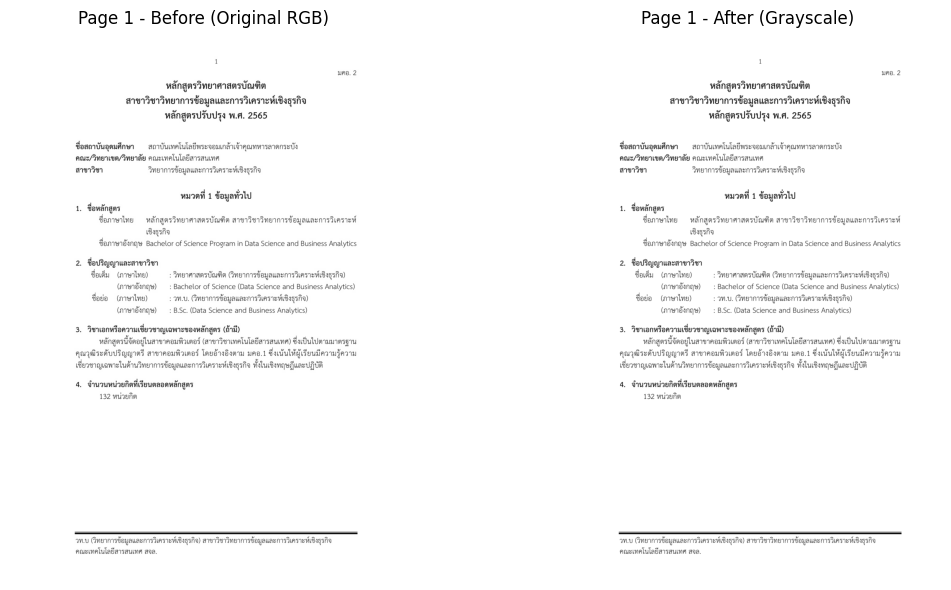

In [112]:

import fitz 

# 1. เปิดไฟล์ PDF
pdf_path = '/Users/pawarit/Downloads/lab2/doc.pdf'
doc = fitz.open(pdf_path)

# 2. เลือกหน้าแรก (ระบบเริ่มนับจาก 0)
page_num = 1
page = doc.load_page(page_num)
pix = page.get_pixmap(dpi=150)

# 3. แปลงหน้า PDF ให้เป็นรูปภาพผ่าน OpenCV
img_bytes = np.frombuffer(pix.tobytes("jpeg"), np.uint8)
img_bgr = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)

# 4. ประมวลผลภาพ --------------------------------------------
# แปลงเป็น RGB เพื่อให้ matplotlib แสดงสีได้ถูกต้อง
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# แยก Channel และแปลงเป็น Grayscale (ตามสูตรที่คุณเขียนไว้)
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
gray = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)
# ---------------------------------------------------------

# 5. --- ส่วนของการแสดงภาพเปรียบเทียบ ก่อน-หลัง สำหรับหน้าแรก ---
plt.figure(figsize=(12, 6))

# พล็อตภาพที่ 1: ก่อนทำ
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Page 1 - Before (Original RGB)')
plt.axis('off') # ปิดแกน x, y

# พล็อตภาพที่ 2: หลังทำ
plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray') # ต้องใส่ cmap='gray' เพื่อบอกให้โชว์เป็นขาวดำ
plt.title('Page 1 - After (Grayscale)')
plt.axis('off')

plt.tight_layout()
plt.show()

# 6. ปิดไฟล์ PDF
doc.close()

# EX2

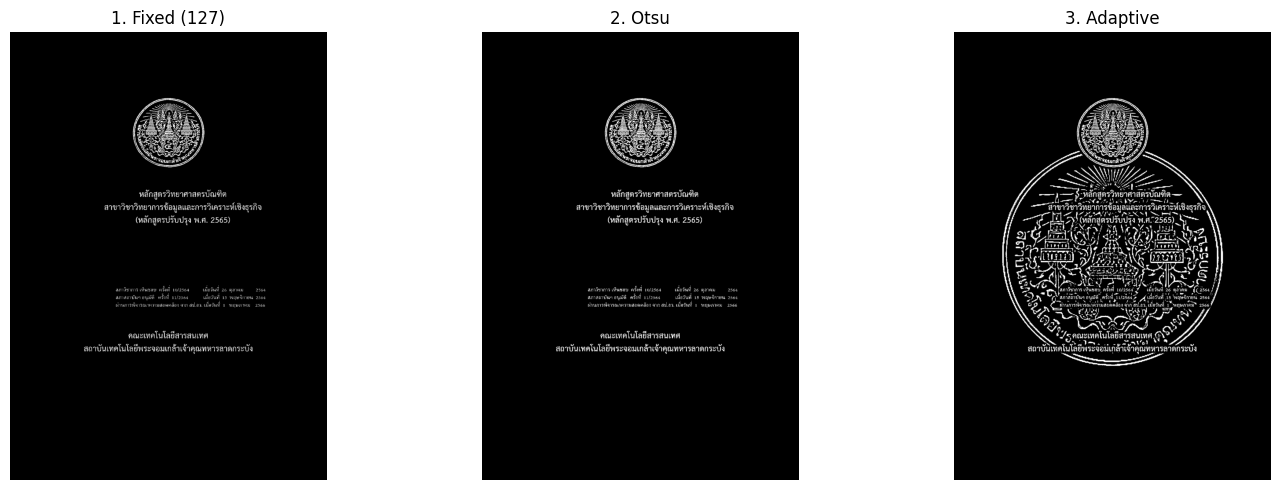

In [ ]:
# 1. Fixed Threshold (กำหนดค่าตายตัวที่ 127)
_, fixed = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# 2. Otsu's Threshold (ให้ระบบคำนวณหาค่าที่ดีที่สุดของทั้งภาพอัตโนมัติ)
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 3. Adaptive Threshold (ปรับค่าตามแสงแต่ละพื้นที่ )
# ต้องเติม blockSize (เช่น 11) และค่า C (เช่น 2)
adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                              cv2.THRESH_BINARY_INV, 31, 10)

# --- พล็อตภาพเปรียบเทียบ ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(fixed, cmap='gray')
plt.title('1. Fixed (127)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(otsu, cmap='gray')
plt.title('2. Otsu')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(adapt, cmap='gray')
plt.title('3. Adaptive')
plt.axis('off')

plt.tight_layout()
plt.show()

ใช้วิธี Adaptive Threshold ได้ผลลัพธ์ที่คมชัดที่สุด ตัวหนังสือดำคมชัด พื้นหลังขาวบริสุทธิ์ เงาทุกอย่างถูกกำจัดออกไปอย่างสมบูรณ์ ทำให้เห็นตัวอักษรคมชัดที่สุดในทุกบริเวณ

# EX3

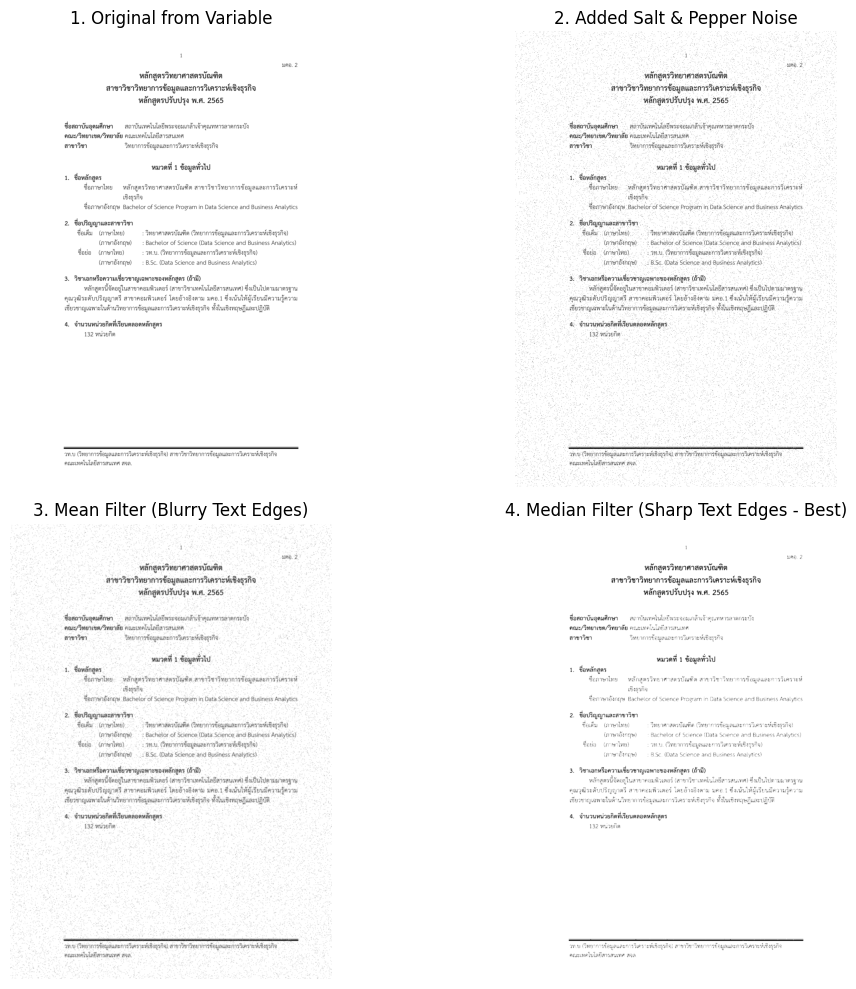

In [113]:
# 1. ฟังก์ชันสำหรับเติมจุดรบกวน (Salt-and-Pepper Noise)
def add_salt_and_pepper(image, amount=0.03):
    noisy = np.copy(image)
    # สุ่มค่าความน่าจะเป็น 0.0 ถึง 1.0
    rand = np.random.rand(*noisy.shape)
    
    # ใส่ Pepper (จุดดำ = 0)
    noisy[rand < (amount / 2)] = 0
    # ใส่ Salt (จุดขาว = 255)
    noisy[rand > 1 - (amount / 2)] = 255
    
    return noisy

# 2. เติม Noise ลงไปในภาพจากตัวแปร g (ใส่ไป 3%)
noisy_img = add_salt_and_pepper(gray, amount=0.03)

# 3. ลบ Noise ตามโจทย์
# วิธีที่ 1: Mean (Averaging) - หาค่าเฉลี่ยในบล็อก 3x3
mean_f = cv2.blur(noisy_img, (3, 3)) 

# วิธีที่ 2: Median (Non-linear) - หาค่ามัธยฐานในบล็อก 3x3
median_f = cv2.medianBlur(noisy_img, 3) 

# 4. แสดงผลเปรียบเทียบ (จัดเป็นกริด 2 แถว 2 คอลัมน์)
plt.figure(figsize=(12, 10))

# ภาพที่ 1: ภาพต้นฉบับจากตัวแปร
plt.subplot(2, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('1. Original from Variable')
plt.axis('off')

# ภาพที่ 2: ภาพที่ถูกเติม Noise
plt.subplot(2, 2, 2)
plt.imshow(noisy_img, cmap='gray')
plt.title('2. Added Salt & Pepper Noise')
plt.axis('off')

# ภาพที่ 3: แก้ด้วย Mean Filter
plt.subplot(2, 2, 3)
plt.imshow(mean_f, cmap='gray')
plt.title('3. Mean Filter (Blurry Text Edges)')
plt.axis('off')

# ภาพที่ 4: แก้ด้วย Median Filter
plt.subplot(2, 2, 4)
plt.imshow(median_f, cmap='gray')
plt.title('4. Median Filter (Sharp Text Edges - Best)')
plt.axis('off')

plt.tight_layout()
plt.show()

Median Filter (cv2.medianBlur): เป็นการเรียงลำดับค่าพิกเซลรอบๆ จากน้อยไปมาก แล้วเลือก "ค่าตรงกลาง (Median)" มาใช้ เนื่องจากจุดรบกวนเป็นค่าสุดโต่ง (0 หรือ 255) มันจึงมักจะไปอยู่หัวหรือท้ายของแถวที่เรียงลำดับแล้วเสมอ ทำให้ค่าตรงกลางที่ถูกเลือกมามักจะเป็นสีพื้นหลังหรือสีตัวอักษรที่แท้จริง วิธีนี้จึงกำจัดจุดรบกวนได้ชะงัดโดยที่ขอบตัวหนังสือยังคงความคมชัดไว้ได้

# EX4

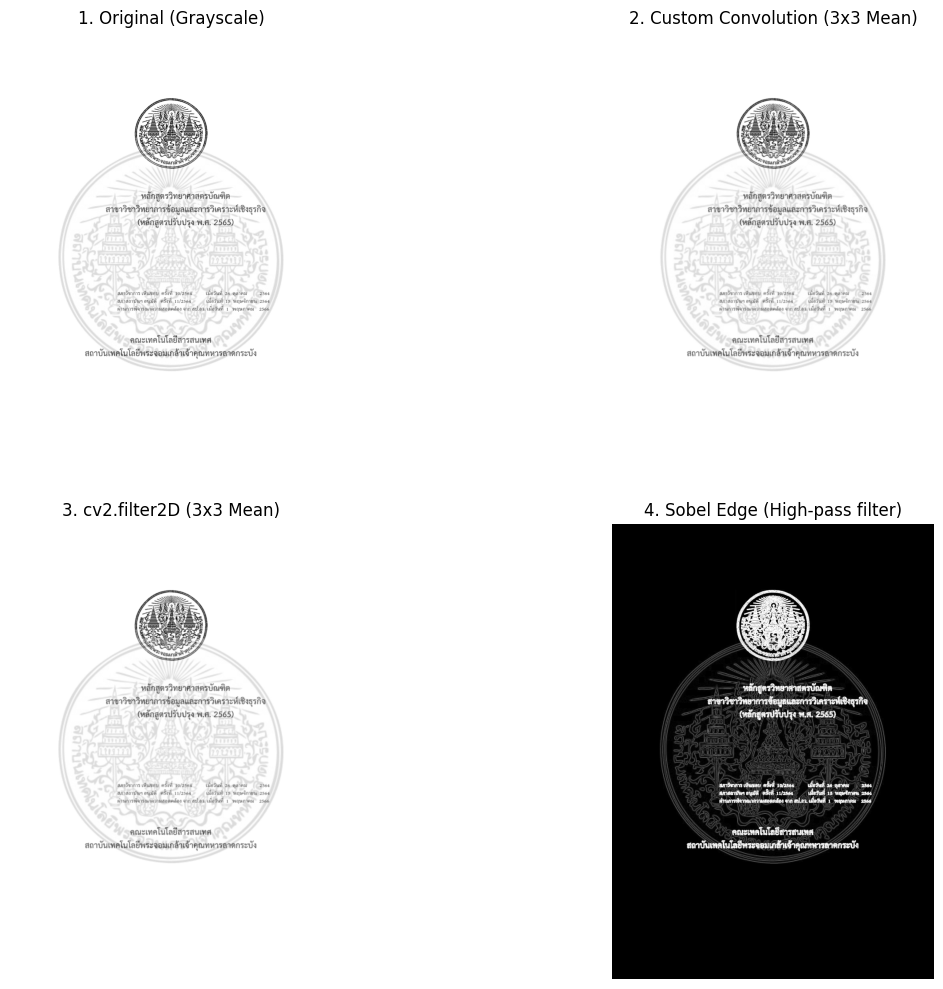

In [107]:
# 1. สร้าง Kernel เฉลี่ย (Mean/Averaging Filter) ขนาด 3x3 (Low-pass)
kernel_3x3 = np.ones((3, 3), np.float32) / 9.0

# 2. เขียน Convolution 2D เอง (เลื่อน Kernel + คูณบวก)
def custom_convolve2d(image, kernel):
    # หาขนาดภาพและขนาด kernel
    h, w = image.shape
    k_h, k_w = kernel.shape
    
    # คำนวณขนาด Padding (สำหรับ kernel 3x3 คือ เติมขอบ 1 พิกเซล)
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # เติมขอบภาพ (Padding) เพื่อให้คำนวณพิกเซลริมขอบได้
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros_like(image, dtype=np.float64)
    
    # กลไก: เลื่อน Kernel (Sliding window) ไปตามแต่ละพิกเซล
    for i in range(h):
        for j in range(w):
            # ดึงพื้นที่ภาพขนาดเท่ากับ kernel
            window = padded_img[i:i+k_h, j:j+k_w]
            # คูณบวก (Element-wise multiplication แล้วจับบวกกัน)
            output[i, j] = np.sum(window * kernel)
            
    return np.clip(output, 0, 255).astype(np.uint8)

# เรียกใช้ฟังก์ชันเขียนเอง (อาจจะใช้เวลาประมวลผลสักครู่เพราะใช้ For loop)
custom_mean = custom_convolve2d(gray, kernel_3x3)

# 3. เทียบกับ OpenCV Filter2D (ได้ผลเหมือนกันแต่เร็วกว่ามาก)
cv2_mean = cv2.filter2D(gray, -1, kernel_3x3)

# 4. ใช้ Sobel หาขอบ (High-pass filter) ดึงความถี่สูง (ตัวอักษร/เส้น)
sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3) # หาขอบแนวตั้ง (แกน X)
sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3) # หาขอบแนวนอน (แกน Y)
# รวมขอบ 2 แกนเข้าด้วยกัน (หาความยาวเส้นทแยงมุม np.hypot)
edge = cv2.convertScaleAbs(np.hypot(sx, sy))

# 5. แสดงผลเปรียบเทียบ
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('1. Original (Grayscale)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(custom_mean, cmap='gray')
plt.title('2. Custom Convolution (3x3 Mean)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv2_mean, cmap='gray')
plt.title('3. cv2.filter2D (3x3 Mean)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(edge, cmap='gray')
plt.title('4. Sobel Edge (High-pass filter)')
plt.axis('off')

plt.tight_layout()
plt.show()

# EX 5

ตรวจพบมุมเอียงโดยประมาณ: 11.75 องศา


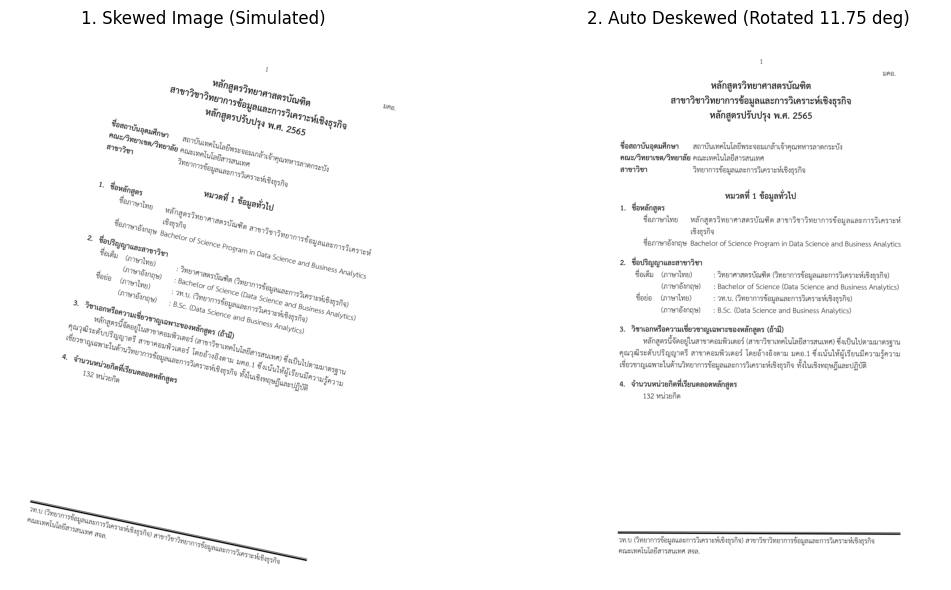

In [114]:
# 1. จำลองการสร้าง "ภาพเอียง" (Skewed Image) จากตัวแปร g
# สมมติให้ภาพเอียงไป -12 องศา
h, w = gray.shape
M_simulate = cv2.getRotationMatrix2D((w//2, h//2), -12, 1.0)
skewed = cv2.warpAffine(gray, M_simulate, (w, h), borderValue=255)

# 2. กระบวนการหา "มุมเอียง" อัตโนมัติ
# 2.1 แปลงเป็นภาพขาวดำ (ตัวหนังสือขาว พื้นดำ) เพื่อให้พิกเซลตัวหนังสือมีค่ามากกว่า 0
_, binary = cv2.threshold(skewed, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2.2 หาพิกัด (y, x) ของพิกเซลที่เป็นตัวอักษรทั้งหมด
coords = np.column_stack(np.where(binary > 0))

# 2.3 ตีกรอบสี่เหลี่ยม (Bounding Box) แบบปรับเอียงได้ ครอบพิกเซลทั้งหมด
# cv2.minAreaRect จะคืนค่า (จุดศูนย์กลาง, (กว้าง, ยาว), องศาความเอียง)
rect = cv2.minAreaRect(coords)
angle = rect[-1]

# 2.4 ปรับค่าองศาให้ถูกต้อง (OpenCV 4.x จะคืนค่ามุมในช่วง 0 ถึง 90 องศา)
if angle > 45:
    angle = angle - 90
elif angle < -45:
    angle = angle + 90
else :
    angle = -angle

print(f"ตรวจพบมุมเอียงโดยประมาณ: {angle:.2f} องศา")

# 3. หมุนภาพกลับให้ตรง
# สร้างเมทริกซ์การหมุน (Rotation Matrix) ที่จุดกึ่งกลางภาพ
M = cv2.getRotationMatrix2D((w//2, h//2),angle, 1.0)

# หมุนภาพกลับ (Warp Affine) โดยใช้ INTER_CUBIC เพื่อรักษาความคมชัดของตัวหนังสือ
# กำหนด borderValue=255 เพื่อให้ขอบภาพที่ถูกหมุนเข้ามาใหม่เป็น "สีขาว"
deskew = cv2.warpAffine(skewed, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)

# 4. แสดงผลเปรียบเทียบ
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(skewed, cmap='gray')
plt.title('1. Skewed Image (Simulated)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(deskew, cmap='gray')
plt.title(f'2. Auto Deskewed (Rotated {angle:.2f} deg)')
plt.axis('off')

plt.tight_layout()
plt.show()